# **Projet: Lutte contre la contrefaçon des billets de banque**

Ce notebook s'inscrit dans un projet de lutte contre la contrefaçon des billets de banque à l'aide de techniques de machine learning.
Il repose sur un jeu de données contenant 1 500 billets, décrits par leurs caractéristiques physiques et leur nature réelle (vrai ou faux).

L'objectif de ce notebook est de préparer les données et d'entraîner plusieurs modèles de classification afin d'évaluer leur capacité à identifier les faux billets.

Les étapes abordées incluent l'exploration des données, la préparation des variables et l'évaluation des performances des modèles.
Les résultats obtenus serviront de base pour le choix du modèle le plus pertinent.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
# Import train test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

import numpy as np
from scipy.stats import mode

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans


from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score
# Function to display the resultst inside the confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

In [7]:
billets_df = pd.read_csv("billets.csv")

# **Fonctions**

### **Prétraitement des données**

Cette section définit l'ensemble du processus, depuis la séparation des données jusqu'à la construction du pipeline, en incluant la standardisation et l'application du modèle.

Cette étape est généralement réalisée avant l'entraînement du modèle afin de distinguer clairement les phases de prétraitement du modèle lui-même, et ainsi éviter toute fuite de données (data leakage).

Une fois correctement défini, le pipeline constitue un flux de travail unique et indépendant, pouvant être appliqué de manière cohérente à l'ensemble des modèles.

In [8]:
# state the data to know
# Args, dataframe and a target
# return a train dataframe and a target feature
def state_data(df, targ):
  X = df.drop(targ, axis=1)
  y = df[targ]
  return X, y

# Tra
def train_split_data(X, y, size, stratify=None):
  X_train_genuine, X_test_genuine, y_train_genuine, y_test_genuine = train_test_split(
      X, y, test_size=size, stratify=stratify, random_state=42
  )
  return X_train_genuine, X_test_genuine, y_train_genuine, y_test_genuine

# build a pipeline to unify a logical and ordered process within a workflow
# make it independent from the rest to avoid data leakage and only associated to the model
def make_pipeline(model, scale=False, pca=False, pca_components=0):
  # instantiate a list
  steps = []
  # need to order it
  if scale == True:
    # first: we scale the data if the model require
    steps.append(("scaler", StandardScaler()))
  # second: we attach the model
  if pca == True:
    steps.append(("pca", PCA(n_components=pca_components)))
  steps.append(("model", model()))
  return Pipeline(steps)

### **Modèles d'évaluation supervisés**

Comme décrit dans la précédente partie qui explique comment les modèles non-supervisés sont prises en compte, cette partie se concentre sur les modèles supervisés and comment les prédictions sont definies.

Dans un entrainement supervisé, un champs cible est toujours requis et séparé des autres données qui permettront d'entrainer le modèle.

La performance du modèle est généralement évalué via une matrice de confusion, qui synthétise le nombre de prédictions divisée en 4 catégories:
- les vrais positifs
- les vrais négatifs
- les faux positifs
- les faux négatifs

In [9]:
def display_results_cm(cm):
  # Create a figure
  TN = cm[0][0]
  FP = cm[0][1]
  FN = cm[1][0]
  TP = cm[1][1]
  TP_rate = TP/(TP+FN)
  TN_rate = TN/(TN+FP)
  FP_rate = FP/(FP+TN)
  FN_rate = FN/(FN+TP)
  accuracy_score = (TP+TN)/(TP+TN+FP+FN)
  f1_score = TP/(TP+0.5*(FP+FN))

  return FP, FN, f1_score


def evaluate_best_model_supervised_training(
    X_train, X_test, y_train, y_test, pipelines, params_classification, scoring="f1"):

  supervised_train_results = []

  for name, pipeline in pipelines.items():
      grid_search = GridSearchCV(pipeline, param_grid=params_classification[name], cv=5, scoring=scoring, n_jobs=-1)
      grid_search.fit(X_train, y_train)
      best_model = grid_search.best_estimator_
      best_score = grid_search.best_score_
      best_params = grid_search.best_params_

      supervised_train_results.append({
      'best_model_name': pipeline.named_steps["model"].__class__.__name__,
      'best_model': pipeline,
      'best_score': best_score,
      'best_params':best_params })
        # We store the results in the list of evaluating models
  best_supervised_results_train = max(supervised_train_results, key=lambda x: x['best_score'])

  return best_supervised_results_train



# this function rr
def evaluate_best_supervised_model_confusion_matrix(X_train, X_test, y_train, y_test, best_supervised_training_model=None):

  if best_supervised_training_model is not None:
    best_trained_model_name = best_supervised_training_model["best_model_name"]
    best_trained_model_instance = best_supervised_training_model["best_model"]
    best_trained_score = best_supervised_training_model["best_score"]
    best_trained_params = best_supervised_training_model["best_params"]

  test_results = []

  # Now we will evaluate each model model also with confusion matrix
  best_trained_model_instance.fit(X_train, y_train)
  y_pred = best_trained_model_instance.predict(X_test)
  cm = confusion_matrix(y_test, y_pred)
  FN, FP, score = display_results_cm(cm)
  cr = classification_report(y_test, y_pred)

  test_results.append({'best_model_name': best_trained_model_name,
                          'best_model': best_trained_model_instance,
                          'best_test_score': score,
                       "FP": FP,
                       "FN": FN,
                       "best_trained_score": best_trained_score,
                       "best_trained_params": best_trained_params,
                          "classification_report": cr })

  best_results_test = max(test_results, key=lambda x: x['best_trained_score'])

  return best_results_test


### **Fonction principale**

All the other fuction can be used independently to specific processing steps when needed or included into a final wrapper function that accepts all relevant parameters, making the overall workflow easier and more convenient to use.

Toutes les autres fonctions peuvent être utilisées de manière indépendante ou incluses dans cette fonction globale. Cela permet de centraliser tous les traitements au sein d'une seule fonction et faciliter les résultats.

In [10]:
def detect_true_false_money(df, colum_target,
                            supervised_pipelines=None,
                            unsupervised_pipelines=None,
                            params_classification=None, params_clustering=None):
  # initiliaze the data
  X_low, y_low = state_data(df, colum_target)

  # split the data into trained model and test set
  X_train_low, X_test_low, y_train_low, y_test_low = train_split_data(X_low, y_low, size=0.2, stratify=y_low)

  if supervised_pipelines is not None:

    # Function for the supervised training and test part
    best_supervised_training_model = \
    evaluate_best_model_supervised_training(X_train_low,
                                X_test_low,
                                y_train_low,
                                y_test_low,
                                supervised_pipelines, params_classification)

    best_supervised_results_test = evaluate_best_supervised_model_confusion_matrix(
    X_train_low, X_test_low, y_train_low, y_test_low, best_supervised_training_model)

  if unsupervised_pipelines is not None:

    # Function for the supervised training and tests part
    best_unsupervised_results = \
    evaluate_unsupervised_model(X_train_low,
                                X_test_low,
                                unsupervised_pipelines, params_clustering)

  return best_unsupervised_results, best_supervised_results_test

### **Autres fonctions**

Autres fonctions permettant de gérer diverses tâches et éviter les redondances

In [11]:
# Calculate the IQR corresponding to 0.75 - 0.25
def calculate_iqr(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  return IQR


# Return the number of rows depeding on the number of cols and the cols given as parameters
# By default, ncols = 1, that mean one element per col

def n_rows(cols, ncols=1):
  n_elements=len(cols)
  return math.ceil(n_elements/ncols)

In [12]:
# import the CSV file
billets_df = pd.read_csv("billets.csv", sep=";")

In [13]:
billets_df.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [14]:
billets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


Certaines valeurs apparaissent manquantes dans le jeu de données.

In [15]:
billets_df.isna().sum()

,0
is_genuine,0
diagonal,0
height_left,0
height_right,0
margin_low,37
margin_up,0
length,0


37 valeurs apparaissent manquantes. L'entreprise souhaite remplacer ces dernières par des valeurs prédites. Pour y parvenir, nous allons décider quel modèle utiliser basé sur différents critères.

In [16]:
for col in billets_df.columns:
    display(billets_df[col].describe())

,is_genuine
count,1500
unique,2
top,True
freq,1000


,diagonal
count,1500.000000
mean,171.958440
std,0.305195
min,171.040000
25%,171.750000
50%,171.960000
75%,172.170000
max,173.010000


,height_left
count,1500.000000
mean,104.029533
std,0.299462
min,103.140000
25%,103.820000
50%,104.040000
75%,104.230000
max,104.880000


,height_right
count,1500.000000
mean,103.920307
std,0.325627
min,102.820000
25%,103.710000
50%,103.920000
75%,104.150000
max,104.950000


,margin_low
count,1463.000000
mean,4.485967
std,0.663813
min,2.980000
25%,4.015000
50%,4.310000
75%,4.870000
max,6.900000


,margin_up
count,1500.000000
mean,3.151473
std,0.231813
min,2.270000
25%,2.990000
50%,3.140000
75%,3.310000
max,3.910000


,length
count,1500.00000
mean,112.67850
std,0.87273
min,109.49000
25%,112.03000
50%,112.96000
75%,113.34000
max,114.44000


# **Définition d'un modèle pour trouver les valeurs manquantes du champs "margin_low"**

D'après les observations précédentes, nous avons remarqué qu’une des variables comportait des valeurs manquantes.
Cette partie se concentrera sur le choix du modèle à utiliser pour gérer et prédire ces valeurs manquantes. Pour sélectionner le modèle le plus approprié, plusieurs critères peuvent être évalués :

- Quel type de variable s'agit-il (numérique ou catégorielle) ?

- Existe-t-il des corrélations avec d'autres variables ?

- Combien de valeurs manquantes sont observées par rapport à la taille du jeu de données ?

Est-ce que le champs contenant les valeurs manquantes a une corrélation forte avec les autres champs?

In [17]:
billets_df["margin_low"].dtype

dtype('float64')

Le champs est de type numérique

## **Corrélations entre le champs cible et les autres**

Existence de corrélations entre le champs cible et les autres champs ?

In [18]:
import seaborn as sns

In [19]:
target_low = "margin_low"

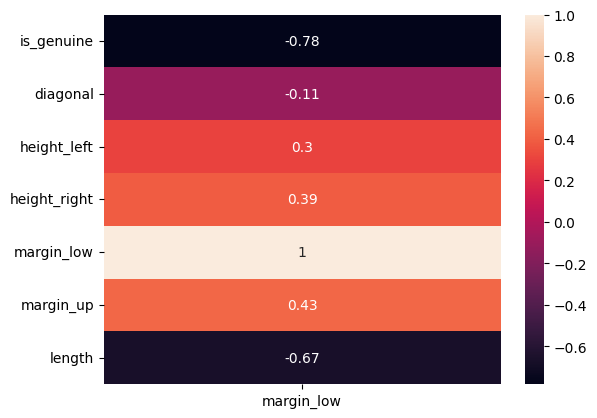

In [20]:
sns.heatmap(billets_df.corr()[[target_low]], annot=True)
plt.show()

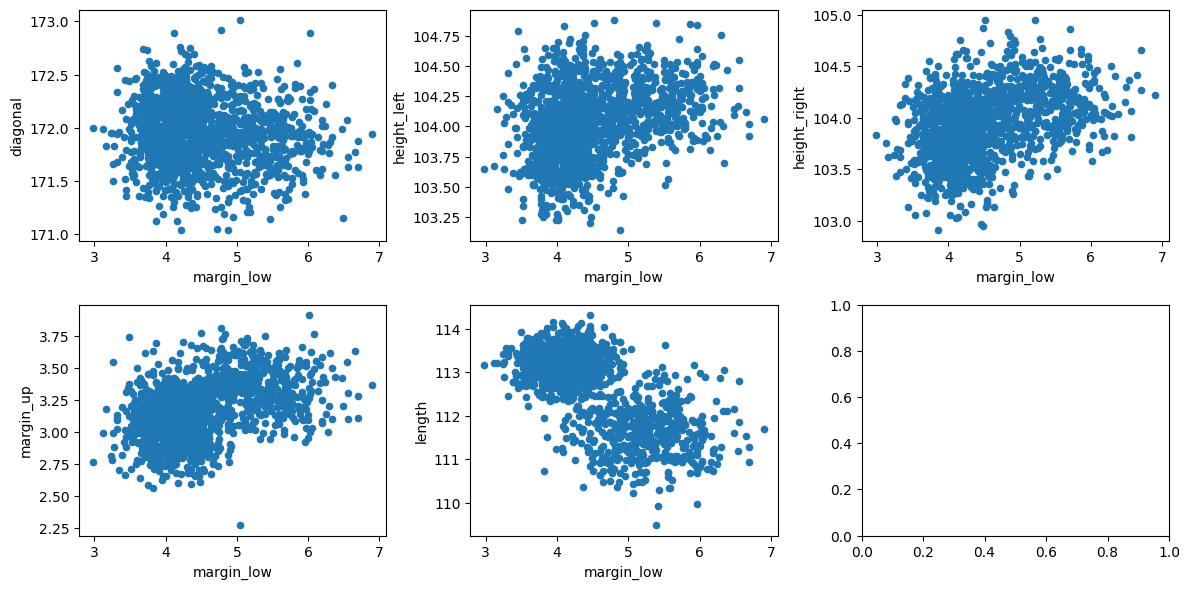

In [21]:
import math

columns_corr=billets_df.drop([target_low, "is_genuine"], axis=1).columns

ncols = 3
nrows = math.ceil(len(columns_corr) / ncols)
fig, axes= plt.subplots(nrows, ncols, figsize=(12,6))
# to flat the axes to avoid multindexes
axes = axes.flatten()

for i, col in enumerate(columns_corr):
  billets_df.plot(
      kind="scatter",
      x=target_low,
      y=col,
      ax=axes[i]
  )
plt.tight_layout()
plt.show()

Tous les champs comparés à "margin_low" excepté "diagonal" sont fortement corrélés négativement ou positivement.

## **Détection des valeurs "outliers"**

Détecter les valeurs "outliers" est une étape importante pour être sûr que les résultats ne seront pas biaisés en raison de la sensibilité de certains modèles. Et même si certains modèles sont plus résistants à ces derniers, les exclure est de manière général une bonne pratique.

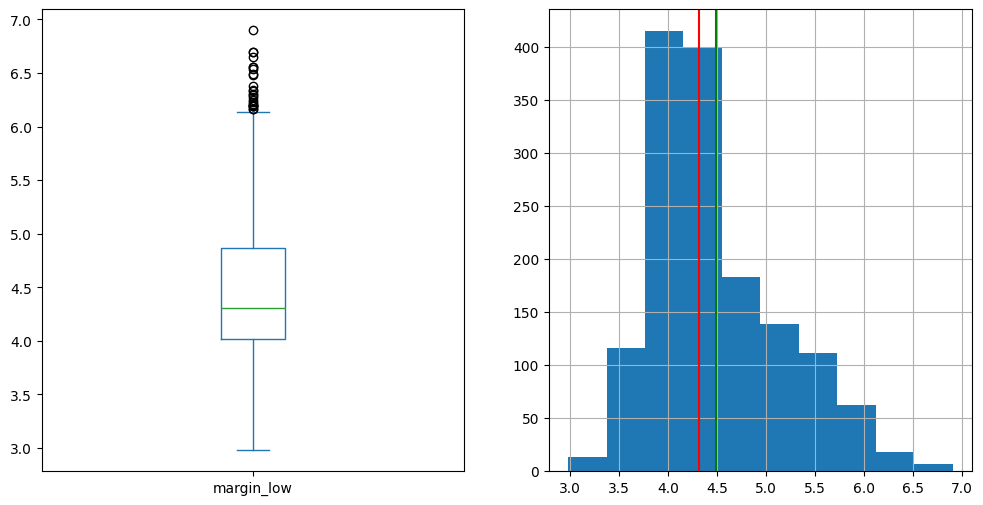

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Check how the margin low is distributed to avoid

billets_df[target_low].plot(kind="box", ax=axes[0])

billets_df[target_low].hist(ax=axes[1])
# display the median line
plt.axvline(billets_df[target_low].median(), color='red')
plt.axvline(billets_df[target_low].mean(), color='green')

plt.show()

In [23]:
billets_df[target_low].describe()

,margin_low
count,1463.000000
mean,4.485967
std,0.663813
min,2.980000
25%,4.015000
50%,4.310000
75%,4.870000
max,6.900000


Comebien de valeurs dites "extrêmes"?

In [24]:
IQR = calculate_iqr(billets_df, target_low)

Method to detect extreme outliers that can affect the results

Savoir s'il existe des valeurs anormalement élevées (3 x l'intervalle interquartile (IQR)

In [25]:
upper_whisker_extreme = billets_df[target_low].quantile(0.75) + 3 * IQR

In [26]:
extreme_outliers = billets_df[billets_df[target_low] > upper_whisker_extreme][target_low]

In [27]:
extreme_outliers_rate = extreme_outliers.count() / billets_df[target_low].count()
print(f"Extreme outliers accounts for \"{target_low}\": {extreme_outliers_rate*100:.2f}%")

Extreme outliers accounts for "margin_low": 0.00%


Pas de valeurs extrêmes. En conséquences, les modèles ne seront pas affectés par ces derniers.

Et des valeurs "outliers" classiques?

In [28]:
upper_whisker_normal = billets_df[target_low].quantile(0.75) + 1.5 * IQR

In [29]:
outliers = billets_df[billets_df[target_low] > upper_whisker_normal][target_low]

In [30]:
outliers_rate = outliers.count() / len(billets_df)
print(f"Outliers for \"{target_low}\": {outliers.count()} over {billets_df[target_low].count()}")
print(f"Outliers rate for \"{target_low}\": {outliers_rate*100:.2f}%")

Outliers for "margin_low": 24 over 1463
Outliers rate for "margin_low": 1.60%


Moins de 3% de valeurs outliers, ce qui réduit leur impact sur les résultats et les performances des modèles.

Pas trop asymétrique, avec quelques valeurs aberrantes observées, mais relativement bien réparti entre les différentes valeurs, la médiane et la moyenne se situant dans la tranche contenant la majorité des données observées.

How many values are missing ?

Combien de valeurs manquantes?

In [31]:
missing_values = billets_df.isna().sum()

In [32]:
missing_rate = missing_values[missing_values > 0] / billets_df.shape[0]
print(f"Missing values rate: {missing_rate.iloc[0] *100:.2f}%")

Missing values rate: 2.47%


Basé sur toutes les données observées précédemment, le champs résultant est de type numérique.

In [33]:
# Filter the row where the margin_low is null
train_data = billets_df[billets_df["margin_low"].notnull()]

# Filter the row where the margin_low is not null
missing_data = billets_df[billets_df["margin_low"].isnull()]
print(missing_data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 37 entries, 72 to 1438
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    37 non-null     bool   
 1   diagonal      37 non-null     float64
 2   height_left   37 non-null     float64
 3   height_right  37 non-null     float64
 4   margin_low    0 non-null      float64
 5   margin_up     37 non-null     float64
 6   length        37 non-null     float64
dtypes: bool(1), float64(6)
memory usage: 2.1 KB
None


## **Définition et construction du modèle de prédiction**

In [34]:
# turn the categorical column into a binary column

X_train_dummies, y = state_data(pd.get_dummies(train_data, columns=['is_genuine'], drop_first=True),
                                      target_low)

# turn the missing values in numerical to get the same shape when predicting missing values
X_missing_dummies = pd.get_dummies(missing_data, columns=['is_genuine'], drop_first=True).drop(target_low, axis=1)

In [35]:
# Train the model
X_train_low, X_test_low, y_train_low, y_test_low = train_split_data(X_train_dummies, y, 0.3)

In [36]:
def evaluate_score_regression_model(model, X_train, X_test, y_train, y_test):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  score = r2_score(y_test, y_pred)
  return score

In [37]:
# from sklearn.linear_model import LinearRegression
linearReg = make_pipeline(LinearRegression, scale=True)

score_linreg_low = evaluate_score_regression_model(linearReg,
                                                   X_train_low,
                                                   X_test_low,
                                                   y_train_low,
                                                   y_test_low)
print(score_linreg_low)

0.6405334834302354


Essayons avec un autre modèle si le score est plus élevé

In [38]:
from sklearn.linear_model import RidgeCV

# Try to confirm with another linear model ridge
paramRidge = {"model__alphas": [0.01, 0.1, 1, 10, 100]}
ridge = make_pipeline(RidgeCV, scale=True)
ridge.set_params(**paramRidge)

score_ridge_low = evaluate_score_regression_model(ridge,
                                                   X_train_low,
                                                   X_test_low,
                                                   y_train_low,
                                                   y_test_low)

print(score_ridge_low)

0.6404572588685216


Pas de différence notable entre Ridge et la régression linéaire.

Essayons aussi d'autres modèles comme DecisionTreeRegressor et RandomForestRegressor pour vérifier si les prédictions sont plus précises.

In [39]:
# Try another model
params_tr = {"model__max_depth":1, "model__random_state":42}
tr = make_pipeline(DecisionTreeRegressor, scale=True)
tr.set_params(**params_tr)
score_tr_low = evaluate_score_regression_model(tr,
                                                   X_train_low,
                                                   X_test_low,
                                                   y_train_low,
                                                   y_test_low)

print(score_tr_low)

0.6366992764369452


In [40]:
# Try another model
params_rf = {"model__n_estimators": 200,
    "model__max_depth": None,
    "model__random_state": 42,
    "model__n_jobs": -1}
rf = make_pipeline(RandomForestRegressor, scale=True)
rf.set_params(**params_rf)
score_rf_low = evaluate_score_regression_model(rf,
                                                   X_train_low,
                                                   X_test_low,
                                                   y_train_low,
                                                   y_test_low)

print(score_rf_low)

0.5936653490881956


In [41]:
models_low_columns = [LinearRegression.__name__,
                      RidgeCV.__name__,
                      DecisionTreeRegressor.__name__,
                      RandomForestRegressor.__name__]
scores_models_low = [score_linreg_low, score_ridge_low, score_tr_low, score_rf_low]

scores_models_low_df = pd.DataFrame(list(zip(models_low_columns, np.round(scores_models_low, 5))),
                                    columns=["Model", "Score"])
scores_models_low_df.sort_values("Score", ascending=False)

,Model,Score
0,LinearRegression,0.64053
1,RidgeCV,0.64046
2,DecisionTreeRegressor,0.63670
3,RandomForestRegressor,0.59367


In [42]:
best_model_low = scores_models_low_df[scores_models_low_df["Score"] == scores_models_low_df["Score"].max()]["Model"].iloc[0]
print(f"The best fitted model is {best_model_low}")

The best fitted model is LinearRegression


La régression linéaire est donc le modèle le plus pertinent par rapport aux autres testés ci-dessus.

In [43]:
predicted_values = linearReg.predict(X_missing_dummies)

In [44]:
# We fill the missing predicted margins low with the values predicted
billets_df.loc[billets_df[target_low].isnull(), target_low] = predicted_values

In [45]:
billets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1500 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


In [46]:
billets_df.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


# **Définition et construction d'un modèle de prédiction performant pour la détection des faux billets**

**Objectifs**: construire un algorithme permettant de réaliser la prédiction la plus précise possible à partir des données de factures.
L'algorithme commencera par évaluer quel modèle offre la meilleure performance sur le jeu d'entraînement, puis appliquera la même logique sur le jeu de test à l'aide d'une matrice de confusion afin d'évaluer combien de cas positifs et négatifs ont été correctement identifiés.

Comment les données sont distribués and s'il existe des corrélations entre les champs

In [47]:
target_false_bills = "is_genuine"

## **Evaluation des données**

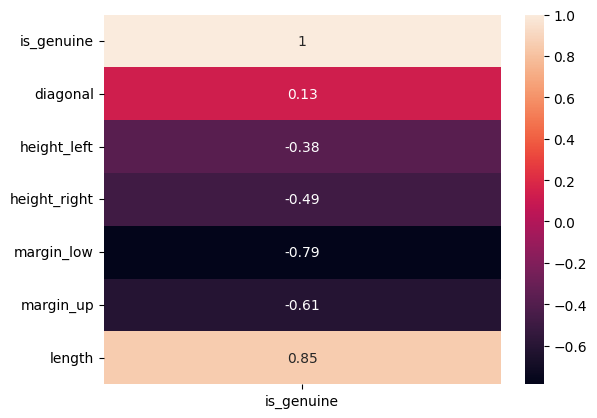

In [48]:
sns.heatmap(data=billets_df.corr()[[target_false_bills]], annot=True)
plt.show()

Vérifions si des outliers apparaissent qui pourraient fausser les résultats

In [49]:
cols_billets = billets_df.drop(target_false_bills, axis=1).columns
ncols=3
nrows = n_rows(cols_billets, ncols)

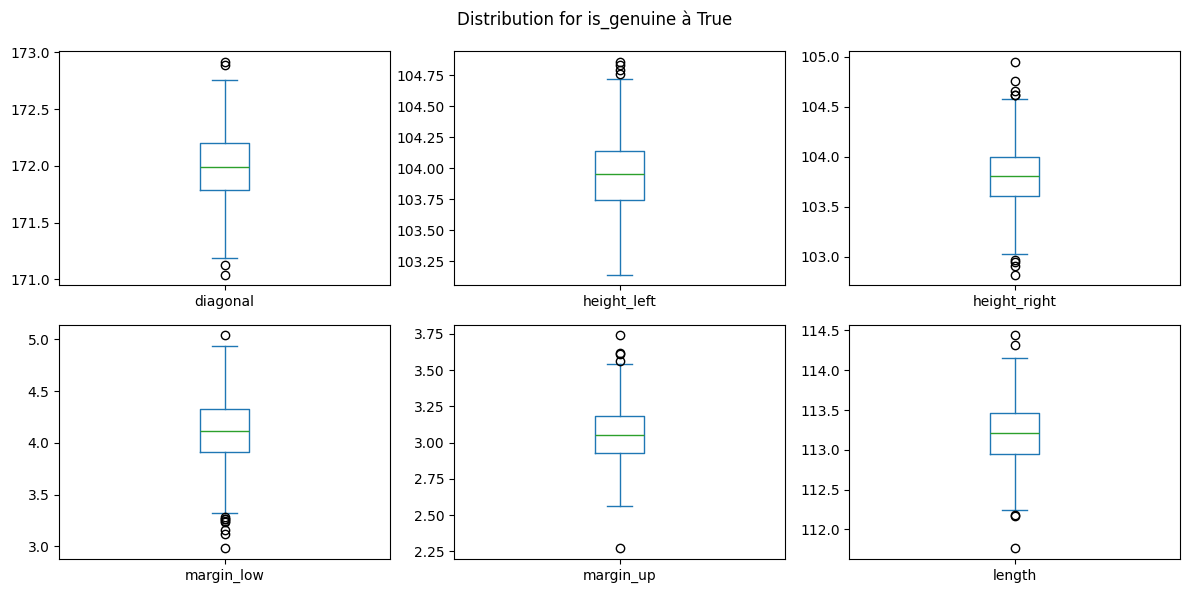

In [50]:
fig, axes = plt.subplots(nrows, ncols, figsize=(12,6))

fig.suptitle("Distribution for is_genuine à True")

ax=axes.flatten()
for i, col in enumerate(cols_billets):
  billets_df.loc[billets_df[target_false_bills]==True, col].plot(kind="box", ax=ax[i])
plt.tight_layout()
plt.show()

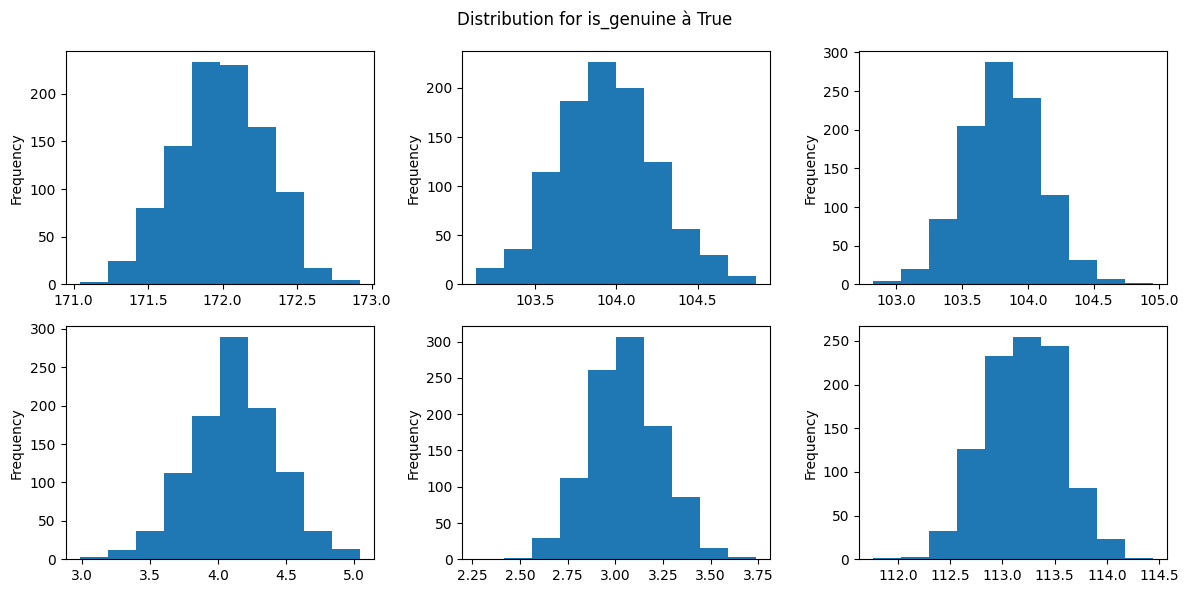

In [51]:
fig, axes = plt.subplots(nrows, ncols, figsize=(12,6))

fig.suptitle("Distribution for is_genuine à True")

ax=axes.flatten()
for i, col in enumerate(cols_billets):
  billets_df.loc[billets_df[target_false_bills]==True, col].plot(kind="hist", ax=ax[i])
plt.tight_layout()
plt.show()

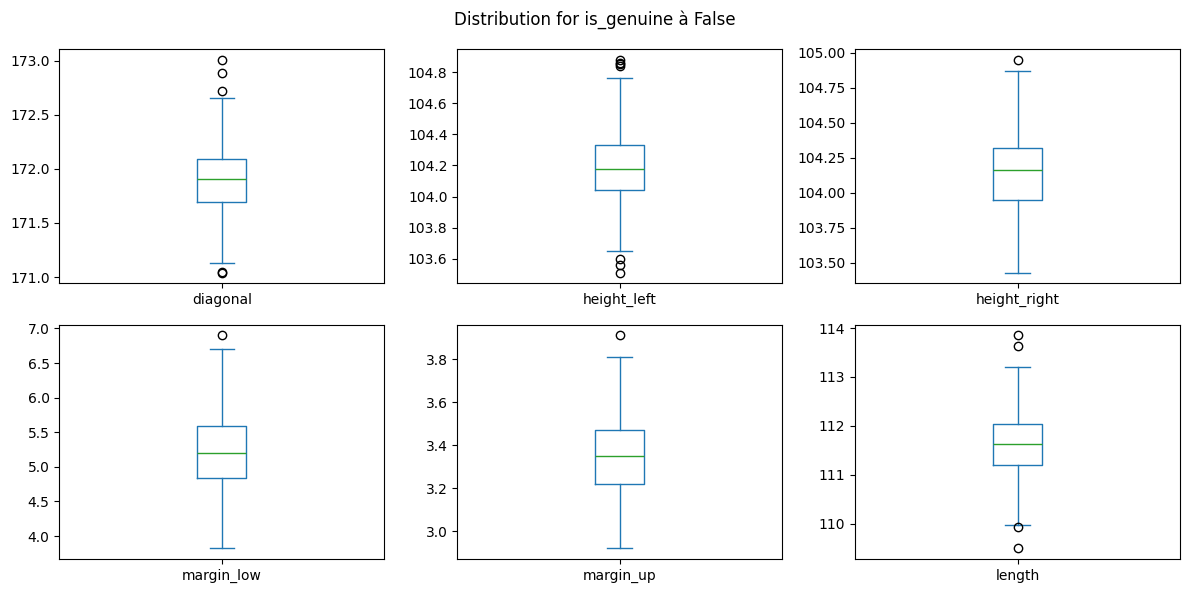

In [52]:
fig, axes = plt.subplots(nrows, ncols, figsize=(12,6))

fig.suptitle("Distribution for is_genuine à False")

ax=axes.flatten()

for i, col in enumerate(cols_billets):
  billets_df.loc[billets_df[target_false_bills]==False, col].plot(kind="box", ax=ax[i])
plt.tight_layout()
plt.show()

Quelques "outliers" semblent apparaitre mais toutes ne semblent pas être trop éloignées de la ligne médiane

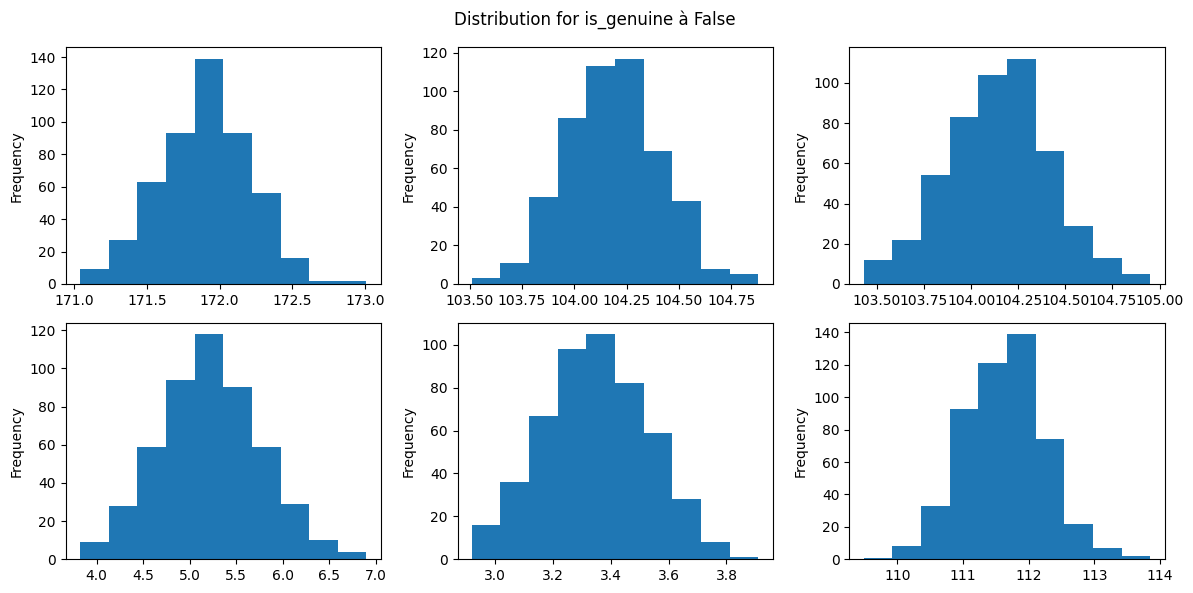

In [53]:
fig, axes = plt.subplots(nrows, ncols, figsize=(12,6))

fig.suptitle("Distribution for is_genuine à False")

ax=axes.flatten()
for i, col in enumerate(cols_billets):
  billets_df.loc[billets_df[target_false_bills]==False, col].plot(kind="hist", ax=ax[i])
plt.tight_layout()
plt.show()

Is Genuine feature distribution between False and True

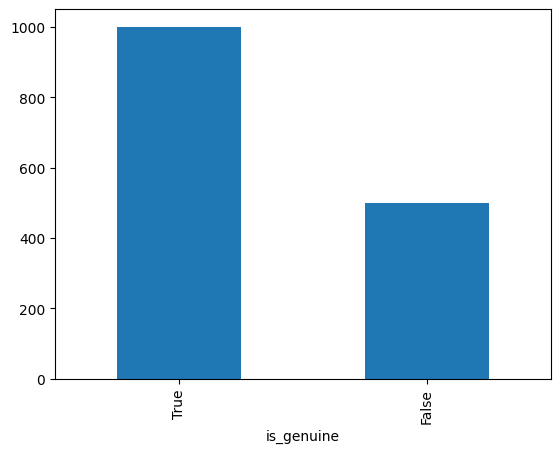

In [54]:
billets_df[target_false_bills].value_counts().plot(kind="bar")
plt.show()

In [55]:
true_genuine = billets_df[billets_df[target_false_bills]==True][target_false_bills].count()
false_genuine = billets_df[billets_df[target_false_bills]==False][target_false_bills].count()

ratio_true_genuine = true_genuine / (true_genuine + false_genuine)
print(f"Ratio true bills: {ratio_true_genuine*100:.2f}%")

Ratio true bills: 66.67%


Le nombre de vrais/faux billets n'étant pas équitablement distribué, un meilleur score doit être appliqué pour entrainer le modèle dans le but de capturer plus efficacement tous les patternes.

Dans ce contexte, le score F1 constitue une métrique plus appropriée, puisqu'il agrège la précision et le rappel en une seule mesure harmonique, permettant d'évaluer l'équilibre entre ces deux dimensions.

## **Fonction principale**

Critères:
- **Champs cible**: "is_genuine" (type boolean) -> problème de classification
- **Champs**: Numérique, distribution égal -> pas de valeurs "outliers" extrêmes
- **Corrélations**: quelques champs sont corrélés entre eux tandis que d'autres ne le sont pas. Des intéractions complexes semblent exister entre ces derniers.

Étant donné ces critères, j'ai choisi de construire un système de prédiction en évaluant cinq modèles différents capables de répondre aux exigences :

- **Régression Logistique** : Choix classique pour les problèmes de classification binaire. Suppose l'existence d'une relation linéaire approximative entre la variable cible et les features, même si celles-ci ne sont pas toutes fortement corrélées.

- **K-Nearest Neighbors (KNN)** : Classificateur non paramétrique basé sur la distance. Utile lorsque les modèles linéaires ne suffisent pas à capturer des motifs plus complexes dans les données.

- **Random Forest Classifier** : Ensemble d'arbres de décision capable de gérer les relations non linéaires entre les features et robuste aux valeurs aberrantes.

- **Decision Tree Classifier** : Modèle non linéaire qui divise les données en fonction des seuils de features. Comme les modèles précédents, il est performant lorsque les features ne sont pas fortement corrélées.

- **K-Means (Clustering)** : Contrairement aux quatre modèles précédents, K-Means est une méthode non supervisée, c'est-à-dire qu'elle n'utilise pas de variable cible. Les données sont regroupées selon leurs caractéristiques communes. Fonctionne mieux sur des données normalisées afin d'éviter les écarts de mesure entre les features.

In [56]:
def evaluate_supervised_model(df, colum_target,
                            supervised_pipelines=None,
                            params_classification=None):
  # initiliaze the data
  X_low, y_low = state_data(df, colum_target)

  # split the data into trained model and test set
  X_train_low, X_test_low, y_train_low, y_test_low = train_split_data(X_low, y_low, size=0.2, stratify=y_low)

  if supervised_pipelines is not None:

    # Function for the supervised training and test part
    best_supervised_training_model = \
    evaluate_best_model_supervised_training(X_train_low,
                                X_test_low,
                                y_train_low,
                                y_test_low,
                                supervised_pipelines, params_classification)

    best_supervised_results_test = evaluate_best_supervised_model_confusion_matrix(
    X_train_low, X_test_low, y_train_low, y_test_low, best_supervised_training_model)


  return best_supervised_results_test

In [57]:

  # Dataframe given
  # A model need to always be involved in a pipeline workflow in order to avoid data leakage
  # and always follow the same logic
supervised_pipelines = {
    "logReg": make_pipeline(LogisticRegression, scale=True),
    "knn": make_pipeline(KNeighborsClassifier, scale=True),
    "rf": make_pipeline(RandomForestClassifier, scale=False),
    "dt" : make_pipeline(DecisionTreeClassifier, scale=False)
  }

  # instantiate the params for the model
params_classification = {
    "logReg": {
        "model__C": [0.1, 1, 10],
        "model__solver": ["lbfgs"],
        "model__max_iter": [1000]
    },
    "knn": {
        "model__n_neighbors": [3, 5, 7],
        "model__weights": ["uniform", "distance"]
    },
    "rf": {
        "model__n_estimators": [100],
        "model__max_depth": [None, 10],
        "model__n_jobs": [-1],
        "model__random_state": [42]
    },
    "dt": {
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [3, 5, None],
        "model__min_samples_split": [2, 10],
        "model__min_samples_leaf": [1, 5],
        "model__random_state": [42]
    }
  }

best_supervised_results_test  = evaluate_supervised_model(
      billets_df, target_false_bills,
      supervised_pipelines,
      params_classification)

print("----------------------------------------------")
print("Test model")
print("----------------------------------------------")
print(f"Best model name on Test: {best_supervised_results_test['best_model_name']}")
print(f"Trained score: {best_supervised_results_test['best_trained_score']:.4f} either {best_supervised_results_test['best_trained_score']*100:.2f}%")
print(f"Trained params: {best_supervised_results_test['best_trained_params']}")
print(f"Test score: {best_supervised_results_test['best_test_score']:.4f} either {best_supervised_results_test['best_test_score']*100:.2f}%")
print(f"False positives: {best_supervised_results_test['FP']}")
print(f"False negatives: {best_supervised_results_test['FN']}")
print(f"Classification report: {best_supervised_results_test['classification_report']}")

----------------------------------------------
Test model
----------------------------------------------
Best model name on Test: KNeighborsClassifier
Trained score: 0.9944 either 99.44%
Trained params: {'model__n_neighbors': 5, 'model__weights': 'uniform'}
Test score: 0.9875 either 98.75%
False positives: 2
False negatives: 3
Classification report:               precision    recall  f1-score   support

       False       0.98      0.97      0.97       100
        True       0.99      0.99      0.99       200

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



# **Evaluation des clusters**

In [58]:
unsupervised_pipelines = {
    "kmeans": make_pipeline(KMeans, scale=True, pca=True, pca_components=2)
}

In [59]:
kmeans_model = unsupervised_pipelines["kmeans"]

kmeans_billets_df = billets_df.copy()

In [60]:
X_kmeans, y_kmeans = state_data(kmeans_billets_df, target_false_bills)

## **Définition des clusters**

Le score silhouette permet de définir pour chaque cluster si les points appartiennent bien à leur groupe et si les groupes sont correctement séparés.

In [61]:
scores = {}
for k in range(2, 12):
  kmeans_model.set_params(model__n_clusters=k)
  kmeans_model.fit(X_kmeans)
  clusters = kmeans_model.predict(X_kmeans)
  score = silhouette_score(X_kmeans, clusters)
  scores[k] = score
scores

{2: np.float64(0.4970289330597311),
 3: np.float64(0.20875589269493156),
 4: np.float64(0.17498781757918702),
 5: np.float64(0.07772811776884248),
 6: np.float64(0.0764203282597452),
 7: np.float64(0.065632051021186),
 8: np.float64(0.05260995192766465),
 9: np.float64(0.04984132860515638),
 10: np.float64(0.04208502455172463),
 11: np.float64(0.030459909263713655)}

In [62]:
number_clusters = max(scores, key=scores.get)
print(number_clusters, "clusters")

2 clusters


In [63]:
kmeans_model.set_params(model__n_clusters=number_clusters, model__random_state=42)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=2)),
                ('model', KMeans(n_clusters=2, random_state=42))])

In [64]:
kmeans_model.fit(X_kmeans)
clusters = kmeans_model.predict(X_kmeans)

## **Réduction des données via les ACP**

Afin de pouvoir mieux visualiser comment les données se regroupent au sein de leur cluster respectif, les données seront réduit via les APC. Ainsi, au lieu d'avoir une multitude de champs à comparer, seulement deux composants seront nécessaire pour capturer la majeur partie des informations.
Et comme dit précédemment, regrouper toutes les données en seulement deux composant permet de simplifier leur visualisation dans un scatter plot.

In [101]:
X_pca = kmeans_model[:-1].transform(X_kmeans)

In [114]:
labels_kmeans = kmeans_model.named_steps["model"].labels_

In [115]:
centroids = kmeans_model.named_steps['model'].cluster_centers_

### **Corrélations ACP <-> champs**

Connaître les corrélations entre la valeur de l'ACP et les différents champs permet est essentiel dans le but de faciliter leurs interprétations.

In [118]:
pca = kmeans_model.named_steps['pca']

In [119]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

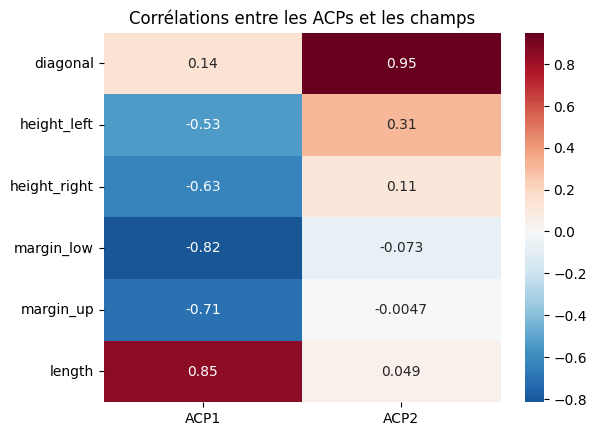

In [126]:
sns.heatmap(
    loadings,
    annot=True,
    cmap='RdBu_r',
    center=0,
    xticklabels=[f"ACP{i+1}" for i in range(loadings.shape[1])],
    yticklabels=X_kmeans.columns
)
plt.title("Corrélations entre les ACPs et les champs")
plt.show()

On observe sur le **premier composant** des corrélations négatives avec la hauteur et la marge des billets et une corrélation positive avec la longeur. Cela signifie des **billets longs et fins**.

On observe sur le **second composant** une corrélation positive sur la longueur de la diagionale du billet. Cela signifie des **billets assez larges**.

### **Visualisation des clusters dans l'espace APC**

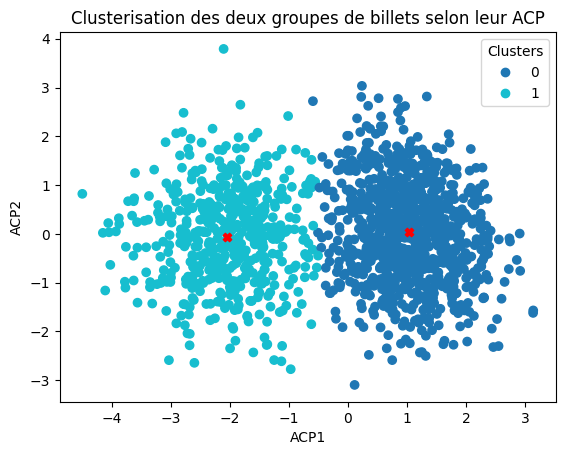

In [127]:
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap="tab10")
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', color="red")
plt.xlabel("ACP1")
plt.ylabel("ACP2")
plt.title("Clusterisation des deux groupes de billets selon leur ACP")
plt.legend(*sc.legend_elements(), title="Clusters")
plt.show()

Les deux clusters ont un centre de gravité plutôt neutre sur le second composant et varient plutôt sur le premier composant. Quand le second cluster a son centre de gravité plutôt sur un ACP1 négatif, le premier est plutôt positif sur cet aspect-là.

Cela signifie que de manière générales les billets du 1er cluster sont plutôt longs et fins tandis que ceux du 2nd cluster représentent l'inverse.

In [67]:
kmeans_billets_df["clusters"] = clusters

In [68]:
kmeans_billets_df

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length,clusters
0,True,171.81,104.86,104.95,4.52,2.89,112.83,1
1,True,171.46,103.36,103.66,3.77,2.99,113.09,0
2,True,172.69,104.48,103.50,4.40,2.94,113.16,0
3,True,171.36,103.91,103.94,3.62,3.01,113.51,0
4,True,171.73,104.28,103.46,4.04,3.48,112.54,0
...,...,...,...,...,...,...,...,...
1495,False,171.75,104.38,104.17,4.42,3.09,111.28,1
1496,False,172.19,104.63,104.44,5.27,3.37,110.97,1
1497,False,171.80,104.01,104.12,5.51,3.36,111.95,1
1498,False,172.06,104.28,104.06,5.17,3.46,112.25,1


In [69]:
pd.crosstab(clusters, y_kmeans)

is_genuine,False,True
row_0,,
0,12,985
1,488,15


## **Evaluation du premier cluster**

In [70]:
mask_cluster_0 = kmeans_billets_df["clusters"]== 0

In [71]:
kmeans_0 = kmeans_billets_df[mask_cluster_0]
kmeans_0

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length,clusters
1,True,171.46,103.36,103.66,3.77,2.99,113.09,0
2,True,172.69,104.48,103.50,4.40,2.94,113.16,0
3,True,171.36,103.91,103.94,3.62,3.01,113.51,0
4,True,171.73,104.28,103.46,4.04,3.48,112.54,0
5,True,172.17,103.74,104.08,4.42,2.95,112.81,0
...,...,...,...,...,...,...,...,...
1267,False,172.13,103.99,103.78,5.47,2.94,112.30,0
1362,False,171.56,103.80,103.87,5.66,2.98,112.95,0
1407,False,172.02,103.99,104.28,4.22,2.98,112.42,0
1412,False,172.25,103.94,103.68,4.14,3.25,112.48,0


In [72]:
mask_true_bills_0 = kmeans_0[target_false_bills] == True

In [73]:
mask_false_bills_0 = kmeans_0[target_false_bills] == False

In [74]:
print(f"{mask_true_bills_0.sum()} vrai(s) billet(s) et {mask_false_bills_0.sum()} faux billet(s)")

985 vrai(s) billet(s) et 12 faux billet(s)


In [75]:
ratio_true_bills_0 = mask_true_bills_0.sum() * 100 / (mask_true_bills_0.sum() + mask_false_bills_0.sum())

In [76]:
print(f"Ratio de vrais billets: {ratio_true_bills_0:.2f}%")

Ratio de vrais billets: 98.80%


## **Evaluation du second cluster**

In [77]:
mask_cluster_1 = kmeans_billets_df["clusters"] == 1

In [78]:
kmeans_1 = kmeans_billets_df[mask_cluster_1]

In [79]:
mask_true_bills_1 = kmeans_1[target_false_bills] == True

In [80]:
mask_false_bills_1 = kmeans_1[target_false_bills] == False

In [81]:
print(f"{mask_true_bills_1.sum()} vrai(s) billet(s) et {mask_false_bills_1.sum()} faux billet(s)")

15 vrai(s) billet(s) et 488 faux billet(s)


In [82]:
ratio_true_bills_1 = mask_true_bills_1.sum() * 100 / (mask_true_bills_1.sum() + mask_false_bills_1.sum())

In [83]:
print(f"Ratio de vrais billets: {ratio_true_bills_1:.2f}%")

Ratio de vrais billets: 2.98%


Dans le **premier cluster**, nous avons un **ratio de 98.61% de vrais billets** avec un nombre total de **1004 billets évalués** et, un **ratio de 2.02% de vrais billets** dans le **second cluster** avec un total de **496 billets évalués**

# **Création d'un fichier CSV de test**

In [84]:
billets_df_cleaned = billets_df.drop(target_false_bills, axis=1)

In [85]:
# Generate the id billets authomatically
billets_df_cleaned["id"] = [f"A_{i+1}" for i in range(0, len(billets_df_cleaned))]

In [86]:
# Generate the cleaned dataset to be test after with the script
billets_df_cleaned.to_csv("billets_df_cleaned.csv", index=False)

# **Récupération du meilleur modèle**

En raison de la présence d'un champs cible, un modèle d'apprentissage supervisé est toujours **plus pertinent**. En effet, grâce à sa relation entre le champs cible et les autres champs, les p**rédictions seront plus précises** et **plus fiables** qu'un modèle non supervisé comme KMeans. De plus, il est plus facile de **généraliser et d'automatiser son application** sur de nouveaux jeux de données, tant que ceux-ci respectent une structure commune.

KMeans par exemple, est beaucoup plus pertinent lorsqu'aucune structure précise n'existe. Il va en ce sens définir comment les données vont se regrouper selon leurs caractéristiquse. Il peut néanmoins compléter les prédictions et voir comment ces dernières se regroupent dans les clusters.

In [87]:
import joblib

joblib.dump(best_supervised_results_test['best_model'], "model.pkl")

['model.pkl']